In [1]:
import os
import sys
from textwrap import wrap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import json
import pandas as pd

from utils.helpers import parse_output

from utils.constants import DEFAULT_AUGMENT_RESULT

from utils.prompts import (
    JUDGE_SYSTEM_PROMPT,
    JUDGE_TEMPLATE,
    AUGMENT_SYSTEM_PROMPT,
    AUGMENT_TEMPLATE,
)

def wrap_text(text, num_chars):
    return '\n'.join(wrap(text, num_chars))

In [2]:
LABELS = ["yes", "no"] # Labels per column
EVAL_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)',
            "Included concepts that were too advanced (Yes/No)\n"]
PRED_COLS = ['augmentedProblemDescription', 'augmentedExampleSolution']

def plot_distributions(df, axes, labels=LABELS, cols=EVAL_COLS):
    fig = axes[0].figure

    for i, col in enumerate(cols):
        sns.countplot(x=df[col], order=labels, ax=axes[i])
        axes[i].set_title(wrap_text(f"{col.upper()}", 20))
        axes[i].set_xlabel("")

    return fig, axes

In [28]:
# Load data
datapath = r"./outputs/results/batch_16653574_result.csv"
augmented_data = pd.read_csv(datapath, sep=";")
#augmented_data.to_excel(datapath.split("/")[-1][:-4] + ".xlsx")

# Remove rows with 'partially' labels
mask_no_partially = (original_dataset[EVAL_COLS] != "partially").all(axis=1)
print("Partially count: " + str(list(mask_no_partially).count(False)))

# Remove erroneous examples
mask_no_errors = (augmented_data[PRED_COLS] != "\"PARSE ERROR\"").all(axis=1)
print("Error count: " + str(list(mask_no_errors).count(False)))

# Keep rows that adhere to the given theme and topic
mask_theme_yes = augmented_data[EVAL_COLS[0]].eq("yes")
mask_topic_yes = augmented_data[EVAL_COLS[1]].eq("yes")

a = (~mask_theme_yes) & (mask_topic_yes)
print(list(a).count(True))


# Keep rows that do not include too advanced concepts
mask_concept_no = augmented_data[EVAL_COLS[-1]].eq("no")
#print("Count of rows dropped: " + str(list(mask_theme_yes).count(False) + list(mask_concept_no).count(False)))

augmented_data = augmented_data[mask_no_errors & mask_theme_topic_yes & mask_concept_no].reset_index()

# Description from JSON string to string
augmented_data[PRED_COLS[0]] = augmented_data[PRED_COLS[0]].map(lambda x: json.loads(x))

# Remove new lines from example solutions to align with original examples
augmented_data[PRED_COLS[1]] = augmented_data[PRED_COLS[1]].map(lambda x: x.replace("\\n", ""))

Partially count: 10
Error count: 11
3


In [5]:
flag = not True
if flag:
    first_occurrence_by_concept = [augmented_data["concept"].eq(concept).idxmax() for concept in augmented_data["concept"].unique()]
    for i in first_occurrence_by_concept:
        row = augmented_data.loc[i]
        
        print("Original topic: " + row["topic"])
        print("Original theme: " + row["theme"])
        print("Origianl concept: " + row["concept"])
        print()
        print("Prompt: \n" + row["prompt"])
        #print("Problem description: ", row["problemDescription"])
        #print("Example solution: ", row["exampleSolution"])
        print()
        print("Augmented problem description: " + row["augmentedProblemDescription"])
        print()
        print("Augmented example solution: " + row["augmentedExampleSolution"])
        print()
        print("-------------------------------------------")
        print()

In [6]:
# Set non-faithful instances to real column
augmented_data["problemDescription"] = augmented_data["augmentedProblemDescription"]
augmented_data["exampleSolution"] = augmented_data["augmentedExampleSolution"]

# Flip labels
augmented_data[EVAL_COLS[0]] = "no"
augmented_data[EVAL_COLS[1]] = "no"
augmented_data[EVAL_COLS[2]] = "yes"


# Drop last three columns: prompt, augmentedProblemDescription, augmentedExampleSolution
augmented_data = augmented_data.iloc[:, :-3]

In [7]:
# Load original dataset
orig = r"./data/complete_dataset.csv"
original_dataset = pd.read_csv(orig, sep=";")

# Remove rows with label 'partially'
mask_no_partially = (original_dataset[EVAL_COLS] != "partially").all(axis=1)
print("Count of rows with 'partially' labels: " + str(list(mask_no_partially).count(False)))
pruned = original_dataset[mask_no_partially].reset_index()

concated_with_pruned = pd.concat([pruned, augmented_data], ignore_index=True).iloc[:,:-1]

Count of rows with 'partially' labels: 10


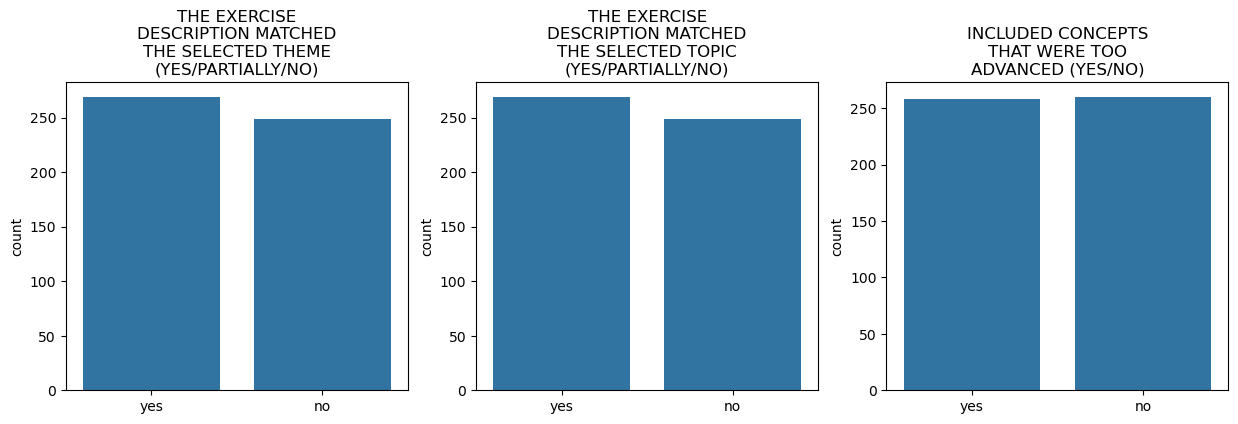

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

plot_distributions(concated_with_pruned, ax)

plt.show()

In [9]:
# Rename columns
final_df = concated_with_pruned.rename(columns={col_name: col_name.replace("/Partially", "").replace("\n", "") for col_name in EVAL_COLS}, errors="raise")

# Take relevant columns
final_df = final_df[[
    "title",
    "problemDescription",
    "exampleSolution",
    "theme",
    "topic",
    "concept",
    "The exercise description matched the selected theme (Yes/No)", 
    "The exercise description matched the selected topic (Yes/No)",
    "Included concepts that were too advanced (Yes/No)"
]]

final_df.head()

,title,problemDescription,exampleSolution,theme,topic,concept,The exercise description matched the selected theme (Yes/No),The exercise description matched the selected topic (Yes/No),Included concepts that were too advanced (Yes/No)
0,Agatha Christie's Novel Ratings,"Agatha Christie, the famous novelist, has a ra...","{'code': ""import 'dart:io'; main() { print(...",literature,Agatha Christie,conditional statements,yes,yes,no
1,Painting Assessment,"In a painting class, the paintings are assesse...","{'code': ""import 'dart:io'; main() { print(...",handicrafts,painting,conditional statements,yes,yes,no
2,Lingonberry Sauce!,Write a program that asks the user for their f...,"{'code': ""import 'dart:io'; main() { print(...",food,Lingonberry sauce,user input,yes,yes,no
3,Mozart's Symphony,Write a program that asks the user for their f...,"{'code': ""import 'dart:io';main() { print('Wh...",classical music,Wolfgang Amadeus Mozart,program output,yes,yes,no
4,Calculate Monopoly rent,"In Monopoly, the rent a player must pay when t...","{'code': ""import 'dart:io'; main() { var ho...",board games,Monopoly,arithmetics,yes,yes,no


In [10]:
#final_df.to_csv("./data/augmented_dataset.csv", sep=";", index=False)

In [11]:
# Stats

stats = final_df.columns[-3:]
columns = pd.MultiIndex.from_tuples([
    ("yes", "Count"),
    ("yes", "Percentage"),
    ("no", "Count"),
    ("no", "Percentage"),
])

len_df = len(final_df)
count_yes = final_df[stats].eq("yes").sum()
count_partially = final_df[stats].eq("partially").sum()
count_no = final_df[stats].eq("no").sum()

data = list(zip(
    count_yes, 100 * count_yes / len_df,
    count_no, 100 * count_no / len_df
))

df_stats = pd.DataFrame(data, index=stats, columns=columns)
#df_stats # Stats match with the source

print(
    df_stats.to_latex(float_format="%.1f")
    .replace("tabular}", "tabularx}{\\textwidth}", 1)
    .replace("tabular}", "tabularx}")
)


#df[label].where(lambda x : x == "yes").dropna().count() / len(df[label])

\begin{tabularx}{\textwidth}{lrrrr}
\toprule
 & \multicolumn{2}{r}{yes} & \multicolumn{2}{r}{no} \\
 & Count & Percentage & Count & Percentage \\
\midrule
The exercise description matched the selected theme (Yes/No) & 269 & 51.9 & 249 & 48.1 \\
The exercise description matched the selected topic (Yes/No) & 269 & 51.9 & 249 & 48.1 \\
Included concepts that were too advanced (Yes/No) & 258 & 49.8 & 260 & 50.2 \\
\bottomrule
\end{tabularx}

